Partie 1 — Préparation et exploration


In [68]:
import pandas as pd

df = pd.read_excel(
    "/app/data/data_brief3.xlsx",
    engine="openpyxl"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,554065,22755,SMALL PURPLE BABUSHKA NOTEBOOK,12,2011-05-22 10:39:00,0.85,18287.0,United Kingdom
1,554065,22754,SMALL RED BABUSHKA NOTEBOOK,12,2011-05-22 10:39:00,0.85,18287.0,United Kingdom
2,554065,22753,SMALL YELLOW BABUSHKA NOTEBOOK,12,2011-05-22 10:39:00,0.85,18287.0,United Kingdom
3,554065,22756,LARGE YELLOW BABUSHKA NOTEBOOK,12,2011-05-22 10:39:00,1.25,18287.0,United Kingdom
4,554065,22758,LARGE PURPLE BABUSHKA NOTEBOOK,12,2011-05-22 10:39:00,1.25,18287.0,United Kingdom


In [69]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [70]:
df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [71]:
df.size

4335272

In [72]:
df.shape

(541909, 8)

In [73]:
df.duplicated().sum()

np.int64(5268)

In [74]:
# negative or zero values
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())

Quantity <= 0: 10624
UnitPrice <= 0: 2517


In [75]:
# removing duplicated rows

df = df.drop_duplicates()

# removing null custmer id

df = df.dropna(subset=["CustomerID"])

# keeping only valid purchases

df = df[(df["Quantity"]>0) & (df["UnitPrice"]>0)]

print(" after cleaning:", df.shape)

 after cleaning: (392692, 8)


In [76]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [77]:
df[["Quantity", "UnitPrice", "TotalPrice"]].head()

,Quantity,UnitPrice,TotalPrice
0,12,0.85,10.2
1,12,0.85,10.2
2,12,0.85,10.2
3,12,1.25,15.0
4,12,1.25,15.0


Partie 2 — Construction du des indicateurs RFM



In [78]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(reference_date)

2011-12-10 12:50:00


In [79]:
rfm = df.groupby("CustomerID").agg(
    Recency = ("InvoiceDate" , lambda x : (reference_date -x.max()).days),
    Frequency = ("InvoiceNo","nunique"),
    Monetary = ("TotalPrice","sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


Partie 3 — Préparation des variables


In [80]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


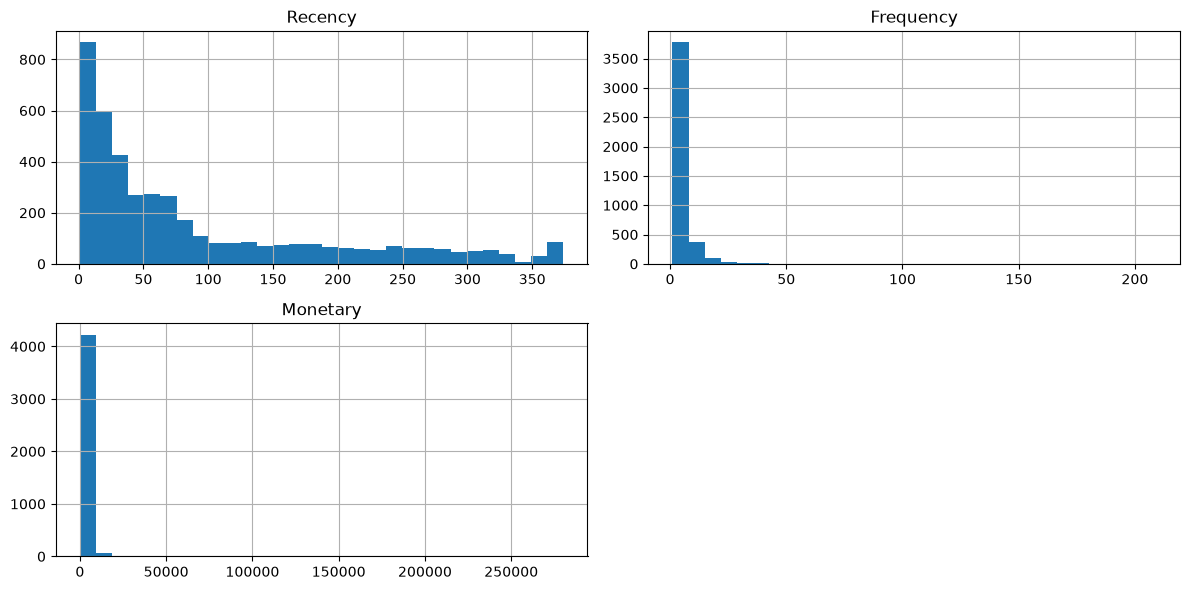

In [81]:
import matplotlib.pyplot as plt

rfm[["Recency", "Frequency", "Monetary"]].hist(
    bins=30,
    figsize=(12,6)
)

plt.tight_layout()
plt.show()

In [82]:
import numpy as np

rfm_log = rfm[["Recency", "Frequency", "Monetary"]].apply(
    lambda x : np.log1p(x)
)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [83]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled[:5]

array([[ 1.46199281, -0.95521426,  3.7077163 ],
       [-2.03873442,  1.07442519,  1.41490344],
       [ 0.37310424,  0.38630445,  0.72002428],
       [-0.62308592, -0.95521426,  0.70228691],
       [ 1.42455753, -0.95521426, -0.61451388]])

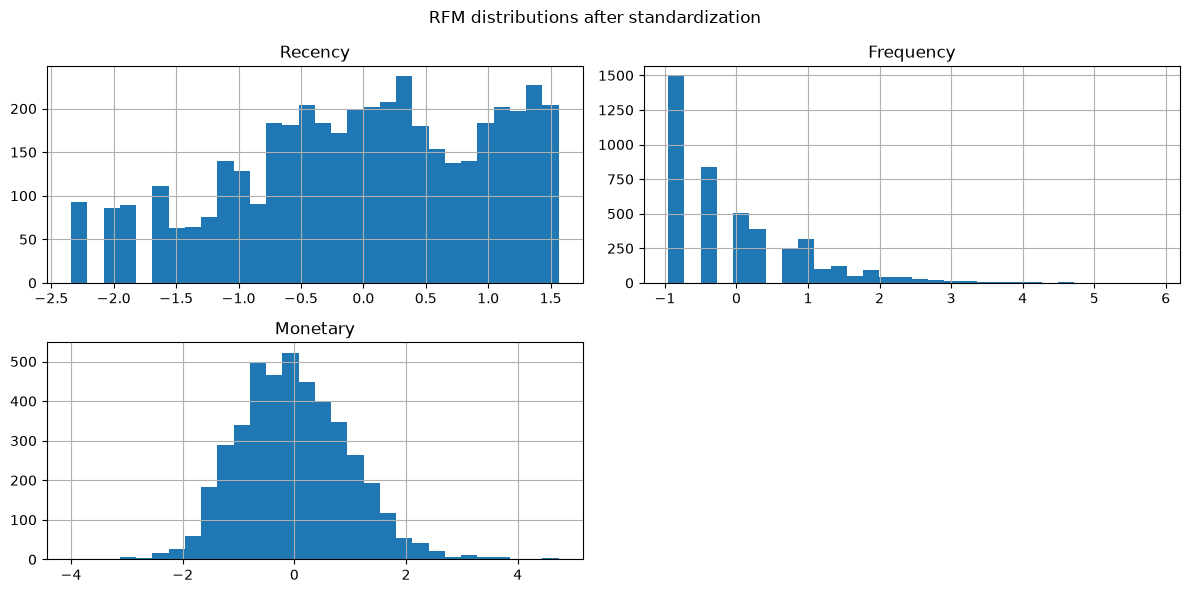

In [84]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns= ["Recency", "Frequency", "Monetary"]
)

rfm_scaled_df.hist(
    bins =30,
    figsize= (12,6)
)

plt.suptitle("RFM distributions after standardization")
plt.tight_layout()
plt.show() 

Partie 4 — Segmentation avec K-Means


In [85]:
from sklearn.cluster import KMeans

inertias = []

for k in range(2,10):
    kmeans = KMeans(
        n_clusters=k,
        random_state= 42 ,
        n_init= 10
    )

    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)

    

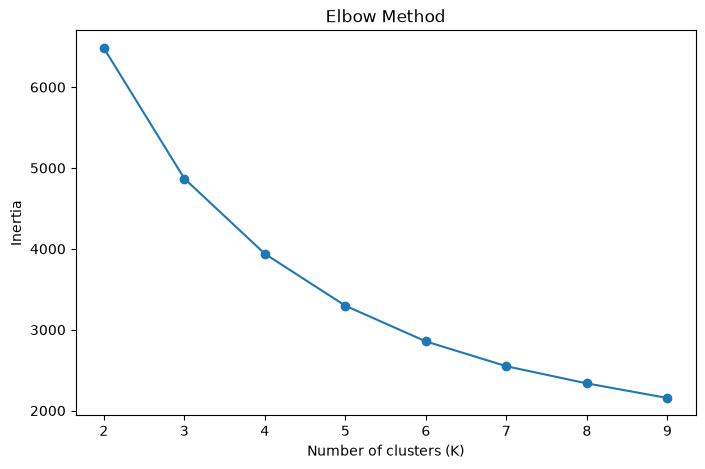

In [86]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,10),
    inertias,
    marker="o"
)

plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [87]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range (2,10):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)
    
    score = silhouette_score(rfm_scaled,labels)
    silhouette_scores.append(score)


In [88]:
for k, score in zip(range(2, 10), silhouette_scores):
    print(f"k={k} : {score:.4f}")

k=2 : 0.4328
k=3 : 0.3365
k=4 : 0.3375
k=5 : 0.3162
k=6 : 0.3124
k=7 : 0.3092
k=8 : 0.3033
k=9 : 0.2811


In [89]:
kmeans = KMeans(
    n_clusters= 3,
    random_state= 42,
    n_init= 10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [90]:
rfm["Cluster"].value_counts()

Cluster
1    1872
2    1697
0     769
Name: count, dtype: int64

Partie 5 — Profiling et interprétation métier


In [91]:
rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,17.062419,13.348505,7898.462003
1,167.358440,1.352030,360.996448
2,44.199764,3.380082,1259.579412


In [102]:
cluster_grouped = rfm.groupby("Cluster")

data = {
        "Count": cluster_grouped.size(),

        "Mean Recency": cluster_grouped["Recency"].mean(),

        "Mean Frequence": cluster_grouped["Frequency"].mean(),

        "Mean Monetary": cluster_grouped["Monetary"].mean(),
        
        "Distribution": (cluster_grouped["Monetary"].sum() / rfm["Monetary"].sum()) * 100,
        
        "Total Monetary": cluster_grouped["Monetary"].sum()
    }

df = pd.DataFrame(data)
# print(df)
df = pd.DataFrame(data)

names = {
    0: "VIP Clients",
    1: "Inactive Clients",
    2: "Regular Clients"
}

df["Segment"] = df.index.map(names)

display(df)

,Count,Mean Recency,Mean Frequence,Mean Monetary,Distribution,Total Monetary,Segment
Cluster,,,,,,,
0,769,17.062419,13.348505,7898.462003,68.344486,6073917.280,VIP Clients
1,1872,167.358440,1.352030,360.996448,7.604022,675785.351,Inactive Clients
2,1697,44.199764,3.380082,1259.579412,24.051491,2137506.263,Regular Clients


In [103]:
print(kmeans.cluster_centers_)

[[-1.12338843  1.63142373  1.40663638]
 [ 0.76736412 -0.76138349 -0.7758602 ]
 [-0.33455304  0.09728978  0.21529215]]


In [107]:
centroids_log = scaler.inverse_transform(kmeans.cluster_centers_)

centroids = np.expm1(centroids_log)

centroids_df = pd.DataFrame(
    centroids,
    columns=["Recency", "Frequency", "Monetary"]
)

print(centroids_df.round(2))

   Recency  Frequency  Monetary
0     9.23      10.70   4265.39
1   127.91       1.28    272.77
2    28.44       3.10    951.86


Partie 6 — Visualisation avec PCA


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)


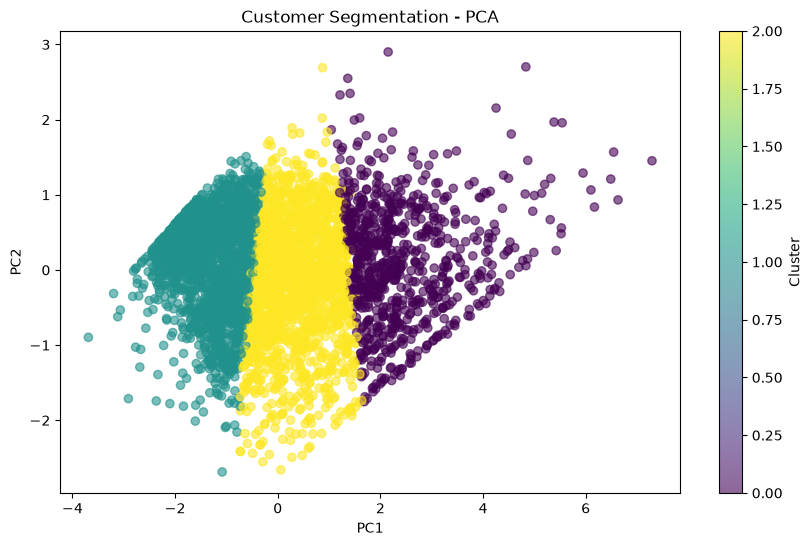

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    rfm_pca[:, 0],
    rfm_pca[:, 1],
    c=rfm["Cluster"],
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation - PCA")
plt.colorbar(label="Cluster")

plt.show()

Partie 7 — Classification avec Random Forest


In [115]:
X = rfm[["Recency", "Frequency", "Monetary"]]
y = rfm["Cluster"]

In [116]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state= 42,
    stratify= y
)

In [119]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators= 10,
    random_state= 42
)

rf.fit(X_train,y_train)

y_pred = rf.predict(X_test)

Partie 8 — Évaluation
